# Exploratory Data Analysis

In this notebook, we perform an EDA on the *Don't Patronize Me!* dataset. The goal is to understand the linguistic properties, class balance, and potential noise in the data before training a binary classifier for detecting PCL.

We will focus on:

* **Statistical Profiling:** Understanding class distribution, sequence lengths, and vocabulary size.
* **Lexical Analysis:** Identifying key n-grams, stop word density, and word clouds.
* **Semantic Analysis:** Exploring tone (POS tags), entities (NER), and embeddings.
* **Noise Detection:** Identifying duplicates, artifacts, and outliers.

## Setup

### Environment Setup

In [1]:
import os
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
from wordcloud import WordCloud

import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

from scipy.stats import mannwhitneyu

In [2]:
sns.set_theme(
    context="paper",
    style="ticks",
    palette="muted",
    font_scale=1.2,
    rc={"figure.figsize": (12, 6), "font.family": "serif"},
)

DATA_DIR = Path(os.getcwd(), "data")
PCL_FILE = os.path.join(DATA_DIR, "dontpatronizeme_pcl.tsv")
TRAIN_IDS_FILE = os.path.join(DATA_DIR, "train_semeval_parids-labels.csv")
DEV_IDS_FILE = os.path.join(DATA_DIR, "dev_semeval_parids-labels.csv")
FIGURES_DIR = os.path.join(os.getcwd(), "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Main PCL File exists: {os.path.exists(PCL_FILE)}")
print(f"Train IDs File exists: {os.path.exists(TRAIN_IDS_FILE)}")
print(f"Dev IDs File exists: {os.path.exists(DEV_IDS_FILE)}")

Main PCL File exists: True
Train IDs File exists: True
Dev IDs File exists: True


### Loading the Dataset

We load the raw dataset `dontpatronizeme_pcl.tsv`.

* **Skip Rows:** The first 4 rows contain a disclaimer.
* **Quoting:** We use `quoting=3` (which corresponds to `csv.QUOTE_NONE`). This is critical because the text fields often contain quotation marks that are part of the content, not field delimiters. If we don't set this, the parser will probably fail or misalign columns.
* **Header:** The file has no header row, so we manually assign column names based on the `README`.

In [3]:
column_names = ["par_id", "art_id", "keyword", "country_code", "text", "label"]
df = pd.read_csv(
    PCL_FILE,
    sep='\t',
    skiprows=4,
    header=None,
    names=column_names,
    quoting=3
)
print(f"Raw Dataset Loaded. Shape: {df.shape}")

Raw Dataset Loaded. Shape: (10469, 6)


In [4]:
# Load the official split IDs
# These files contain the paragraph IDs (par_id) corresponding to the official train and dev sets.
train_ids_df = pd.read_csv(TRAIN_IDS_FILE)
dev_ids_df = pd.read_csv(DEV_IDS_FILE)

print(f"Train IDs loaded: {len(train_ids_df)}")
print(f"Dev IDs loaded: {len(dev_ids_df)}")

Train IDs loaded: 8375
Dev IDs loaded: 2094


We inspect the first few rows to ensure the columns are aligned correctly. Specifically, we check that the text column contains actual text and the label column contains integers (0-4).

In [5]:
display(df.head())

print("Dataset Info:")
print(df.info())

,par_id,art_id,keyword,country_code,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10469 entries, 0 to 10468
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   par_id        10469 non-null  int64
 1   art_id        10469 non-null  str  
 2   keyword       10469 non-null  str  
 3   country_code  10469 non-null  str  
 4   text          10468 non-null  str  
 5   label         10469 non-null  int64
dtypes: int64(2), str(4)
memory usage: 3.3 MB
None


* **Missing Values:** The `df.info()` output shows 10,468 non-null values in the text column against 10,469 entries total. We have 1 missing value to handle.
    * That sample is actually in the official development split.
    * It wouldn't be considered anyway in the EDA since we only inspect the training split.
* **Label Integrity:** The labels are integers, confirming the rows were parsed correctly.

### Basic Data Preprocessing

This section handles three critical tasks:

* **Cleaning:** Removing the single missing value we identified.
* **Label Engineering:** Converting the original 0-4 scale into the binary format (PCL vs. no-PCL).
* **Data Splitting:** Applying the official SemEval train/dev splits so our EDA is performed on the correct subset.

In [6]:
df = df.dropna(subset=["text"]).copy()

df["binary_label"] = df["label"].apply(lambda x: 1 if x >= 2 else 0)

df["par_id"] = df["par_id"].astype(str)
train_ids_df["par_id"] = train_ids_df["par_id"].astype(str)
dev_ids_df["par_id"] = dev_ids_df["par_id"].astype(str)
train_df = df[df["par_id"].isin(train_ids_df["par_id"])].copy()
dev_df = df[df["par_id"].isin(dev_ids_df["par_id"])].copy()

# Reset indexes for clean manipulation
train_df.reset_index(drop=True, inplace=True)
dev_df.reset_index(drop=True, inplace=True)

In [7]:
# Sanity check: ensure no overlap between train and dev
overlap = set(train_df["par_id"]).intersection(set(dev_df["par_id"]))
print(f"Original Dataset Size:          {len(df)}")
print(f"Training Set Size:              {len(train_df)}")
print(f"Dev Set Size:                   {len(dev_df)}")
print(f"Overlap between Train and Dev:  {len(overlap)}")

Original Dataset Size:          10468
Training Set Size:              8375
Dev Set Size:                   2093
Overlap between Train and Dev:  0


## Basic Statistical Profiling

### Class Distribution Analysis

We analyze the ratio of PCL vs. No-PCL examples to determine the severity of class imbalance.

In [8]:
class_counts = train_df["binary_label"].value_counts()
neg_count = class_counts[0]
pos_count = class_counts[1]
imbalance_ratio = neg_count / pos_count

print(f"Class Counts (Train Set):")
print(f"No PCL (0): {neg_count}")
print(f"PCL (1):    {pos_count}")
print(f"Imbalance Ratio: 1 PCL example for every {imbalance_ratio:.2f} No-PCL examples")

Class Counts (Train Set):
No PCL (0): 7581
PCL (1):    794
Imbalance Ratio: 1 PCL example for every 9.55 No-PCL examples


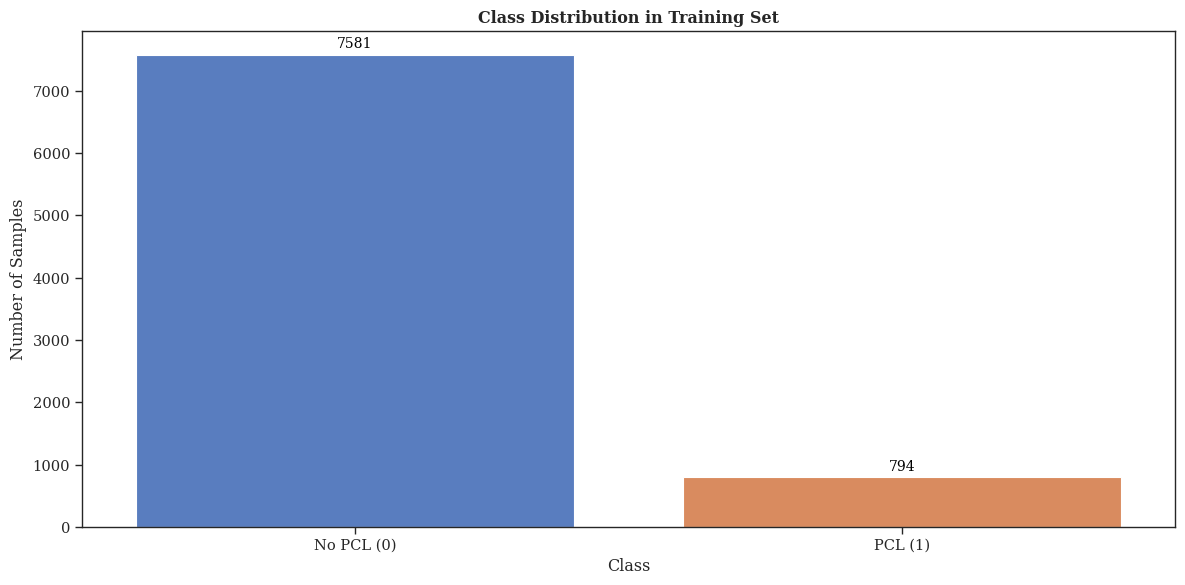

In [9]:
ax = sns.countplot(
    data=train_df,
    x="binary_label",
    hue="binary_label",
    legend=False
)
plt.title("Class Distribution in Training Set", fontweight="bold")
plt.xticks([0, 1], ["No PCL (0)", "PCL (1)"])
plt.xlabel("Class")
plt.ylabel("Number of Samples")

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()),
        ha="center", va="baseline", fontsize=10, color="black", xytext=(0, 5), textcoords="offset points"
    )
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * The dataset is heavily imbalanced with 7,581 negative samples (no-PCL) and only 794 positive samples (PCL). This results in an imbalance ratio of roughly 9.5:1.
> * Accuracy is a misleading metric here. A baseline model predicting no-PCL for every input would achieve ~90.5% accuracy. We must consider the F1-score, precision, recall, and the AUPRC.
> * We need to handle this skew. That could involve data augmentation, weighted random sampling during batching, or loss-level adjustments.

### Sequence Length Analysis

In [10]:
# Calculate word count by simple whitespace splitting
train_df["seq_len"] = train_df["text"].apply(lambda x: len(str(x).split()))

print("Sequence Length Statistics (Words):")
print(train_df['seq_len'].describe())

Sequence Length Statistics (Words):
count    8375.000000
mean       48.675224
std        29.677952
min         1.000000
25%        30.000000
50%        42.000000
75%        60.000000
max       909.000000
Name: seq_len, dtype: float64


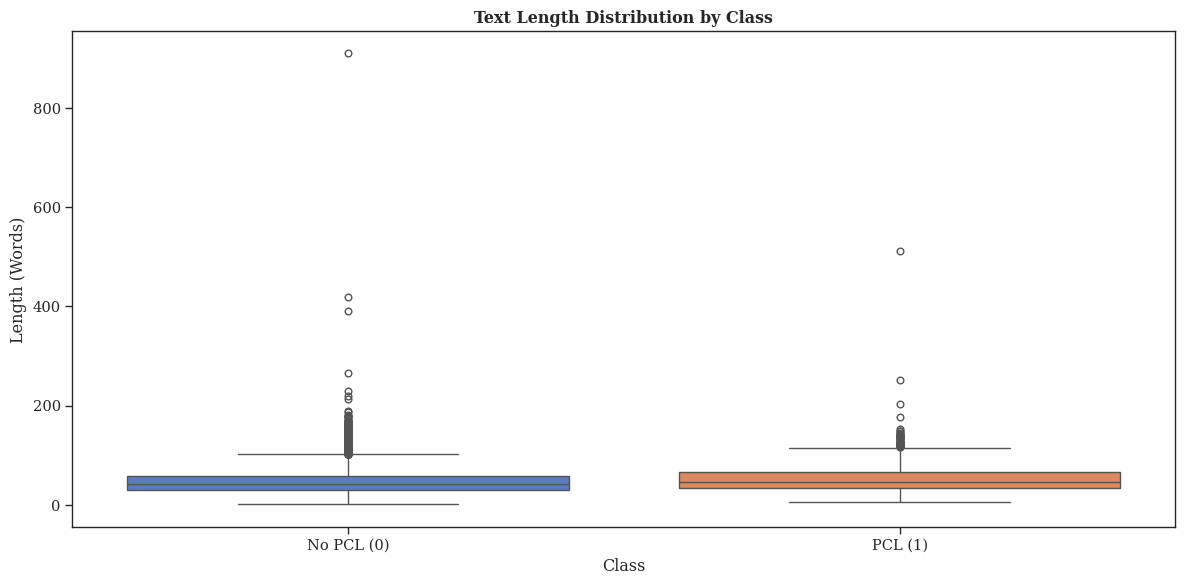

In [11]:
sns.boxplot(
    data=train_df,
    x="binary_label",
    y="seq_len",
    hue="binary_label",
    legend=False
)

plt.title("Text Length Distribution by Class", fontweight="bold")
plt.xticks([0, 1], ["No PCL (0)", "PCL (1)"])
plt.xlabel("Class")
plt.ylabel("Length (Words)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sequence_lengths.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * The text length distribution is surprisingly similar for both classes. The mean length is ~49 words, with a median of 42 words. While the maximum length reaches 909 words, the 75th percentile is only 60 words.
> * RoBERTa uses a BPE tokenizer. A `max_length` of 256 tokens is more than enough to cover the data without truncation.
> * Since PCL samples are not distinctively longer or shorter than neutral texts, length is not a proxy feature the model can exploit.

### Vocabulary Size

We calculate the number of unique words (tokens) in the dataset.
* **Relevance:** A small vocabulary implies simple language; a massive one implies complex, diverse, or noisy text. This dictates the size of the embedding layer in neural models.

In [12]:
# Tokenize all text by splitting on whitespace (simple approximation)
all_tokens = [word for text in train_df["text"] for word in str(text).lower().split()]
unique_tokens = set(all_tokens)

print(f"Total Tokens: {len(all_tokens)}")
print(f"Vocabulary Size (Unique Tokens):    {len(unique_tokens)}")
print(f"Lexical Diversity (Unique / Total): {len(unique_tokens) / len(all_tokens) * 100:.2f}%")

Total Tokens: 407655
Vocabulary Size (Unique Tokens):    29966
Lexical Diversity (Unique / Total): 7.35%


> **Analysis & Impact:**
> * We identified 29,966 unique tokens across the training set, with a lexical diversity of 7.35%.
> * The vocabulary size is moderate. The low lexical diversity suggests a repetitive, domain-specific language (news/humanitarian reports).
> * This reinforces the need for a pre-trained language model like BERT or RoBERTa, which already understands these domains, rather than training embeddings from scratch.

## Lexical Analysis

### N-Gram Analysis

We extract the most frequent bigrams (2-word phrases) for both classes.

In [13]:
# Download stopwords if not already present
nltk.download("stopwords", quiet=True)
stop_words = list(stopwords.words("english"))

def get_top_ngrams(corpus, n=2, top_k=15):
    # We use a simple regex pattern for tokens to ignore punctuation
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words, token_pattern=r"\b[a-zA-Z]{3,}\b").fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

In [14]:
pcl_text = train_df[train_df["binary_label"] == 1]["text"].astype(str)
no_pcl_text = train_df[train_df["binary_label"] == 0]["text"].astype(str)

top_pcl_bigrams = get_top_ngrams(pcl_text, n=2, top_k=15)
top_no_pcl_bigrams = get_top_ngrams(no_pcl_text, n=2, top_k=15)

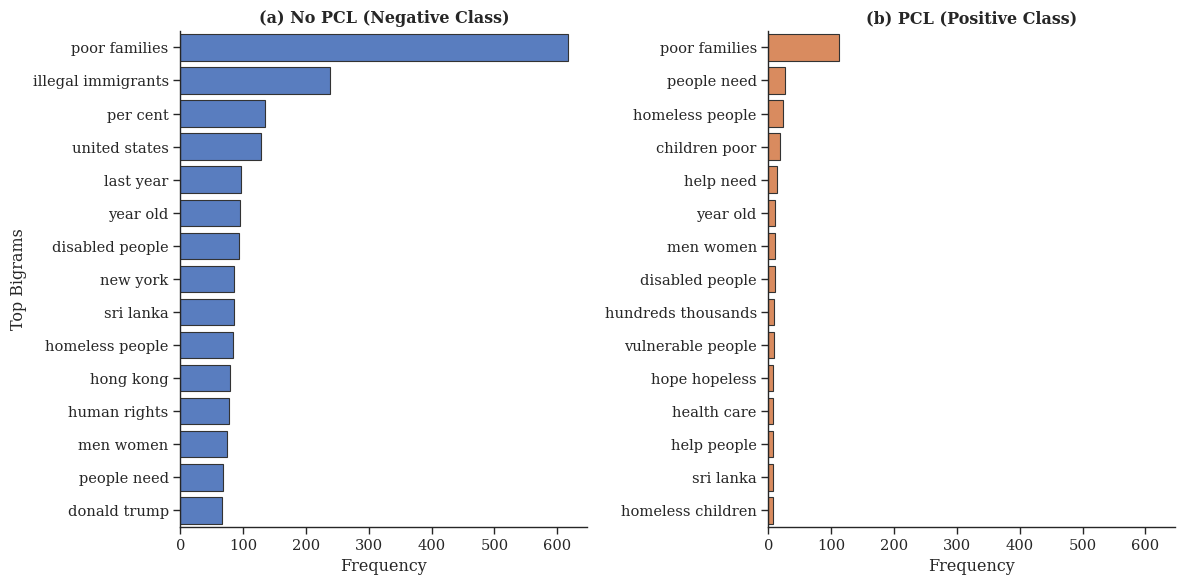

In [15]:
df_pcl_bi = pd.DataFrame(top_pcl_bigrams, columns=["Bigram", "Frequency"])
df_no_pcl_bi = pd.DataFrame(top_no_pcl_bigrams, columns=["Bigram", "Frequency"])

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
colors = sns.color_palette("muted")

sns.barplot(
    ax=axes[0],
    x="Frequency",
    y="Bigram",
    data=df_no_pcl_bi,
    color=colors[0],
    edgecolor=".2"
)
axes[0].set_title("(a) No PCL (Negative Class)", fontweight="bold")
axes[0].set_ylabel("Top Bigrams")
axes[0].set_xlabel("Frequency")

sns.barplot(
    ax=axes[1],
    x="Frequency",
    y="Bigram",
    data=df_pcl_bi,
    color=colors[1],
    edgecolor=".2"
)
axes[1].set_title("(b) PCL (Positive Class)", fontweight="bold")
axes[1].set_ylabel('')
axes[1].set_xlabel("Frequency")

sns.despine()
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "bigram_comparison.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * The bigram `poor families` is the #1 most frequent bi-gram for both classes. While there are some differences (e.g., the positive class featuring more emotive terms), there are also many commonalities.
> * A simple BoWs model will likely fail because key bi-grams like `poor families` are ambiguous. The model must learn the context surrounding these words.

### Stop Word Density

We measure the percentage of "filler" words to see if PCL is more verbose or structural.

In [16]:
stop_words_set = set(stop_words)

def calculate_stop_density(text):
    tokens = str(text).lower().split()
    if not tokens: return 0
    stop_count = sum(1 for t in tokens if t in stop_words_set)
    return stop_count / len(tokens)

train_df["stop_density"] = train_df["text"].apply(calculate_stop_density)

print(f"Avg Stop Word Density (No PCL): {train_df[train_df["binary_label"]==0]["stop_density"].mean():.2f}")
print(f"Avg Stop Word Density (PCL):    {train_df[train_df["binary_label"]==1]["stop_density"].mean():.2f}")

Avg Stop Word Density (No PCL): 0.37
Avg Stop Word Density (PCL):    0.40


> **Analysis & Impact:**
> * The PCL class has a slightly higher stop word density (40%) compared to the no-PCL class (37%).
> * The difference is most likely not significant enough to condition the model on it.

### Word Clouds

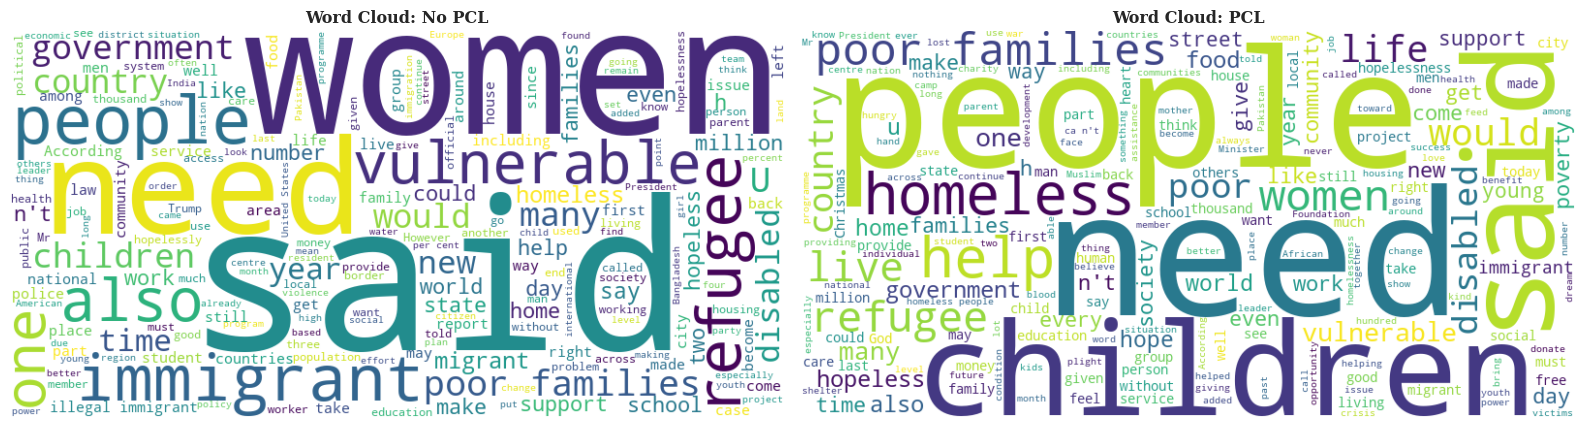

In [17]:
def plot_wordcloud(text_series, title):
    text_combined = ' '.join(text_series.astype(str))
    wc = WordCloud(width=800, height=400, background_color="white", stopwords=stop_words_set).generate(text_combined)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontweight="bold")

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_wordcloud(train_df[train_df["binary_label"]==0]["text"], "Word Cloud: No PCL")
plt.subplot(1, 2, 2)
plot_wordcloud(train_df[train_df["binary_label"]==1]["text"], "Word Cloud: PCL")
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "word_clouds.pdf"), bbox_inches="tight", dpi=300)
plt.show()

## Semantic & Syntactic Exploration

### Part-of-Speech (POS) Tagging

We test the hypothesis that PCL is adjective-heavy using POS density analysis.

In [18]:
nltk.download("punkt", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

def get_pos_density(text):
    tokens = nltk.word_tokenize(str(text))
    if not tokens:
        return 0, 0

    tags = nltk.pos_tag(tokens)

    # Count tags starting with 'JJ' (adjectives) and 'VB' (verbs)
    adj_count = sum(1 for word, tag in tags if tag.startswith("JJ"))
    verb_count = sum(1 for word, tag in tags if tag.startswith("VB"))

    # Return density (count / total_tokens)
    return adj_count / len(tokens), verb_count / len(tokens)

In [19]:
pos_data = train_df["text"].apply(get_pos_density)
train_df["adj_density"] = [x[0] for x in pos_data]
train_df["verb_density"] = [x[1] for x in pos_data]

/var/folders/6s/yjy_9z7d7g12xst_ztz56chm0000gn/T/ipykernel_38122/1787062745.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["No PCL (0)", "PCL (1)"])


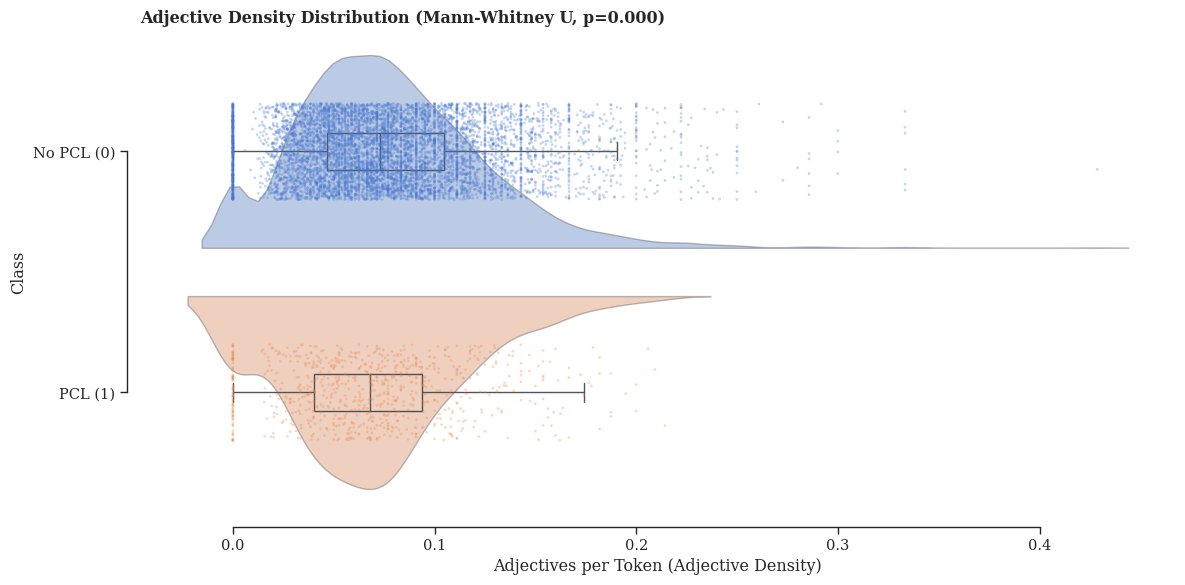

In [20]:
g0 = train_df[train_df["binary_label"] == 0]["adj_density"]
g1 = train_df[train_df["binary_label"] == 1]["adj_density"]
u_stat, p_val = mannwhitneyu(g0, g1)

fig, ax = plt.subplots(figsize=(12, 6))

# density
sns.violinplot(
    data=train_df,
    x="adj_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    palette="muted",
    inner=None,
    split=True,
    alpha=0.4,
    ax=ax,
    legend=False
)

# individual points
sns.stripplot(
    data=train_df,
    x="adj_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    palette="muted",
    size=2,
    alpha=0.3,
    jitter=0.2,
    ax=ax,
    legend=False
)

# summary stats
sns.boxplot(
    data=train_df,
    x="adj_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    palette="muted",
    width=0.15,
    showfliers=False,
    boxprops={"facecolor": "none", "edgecolor": "0.3"},
    ax=ax,
    legend=False
)

plt.title(
    f"Adjective Density Distribution (Mann-Whitney U, p={p_val:.3f})",
    loc="left",
    fontweight="bold"
)
ax.set_yticklabels(["No PCL (0)", "PCL (1)"])
ax.set_ylabel("Class")
ax.set_xlabel("Adjectives per Token (Adjective Density)")

sns.despine(trim=True, offset=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "adjective_density.pdf"), bbox_inches="tight", dpi=300)
plt.show()

/var/folders/6s/yjy_9z7d7g12xst_ztz56chm0000gn/T/ipykernel_38122/2547071423.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["No PCL (0)", "PCL (1)"])


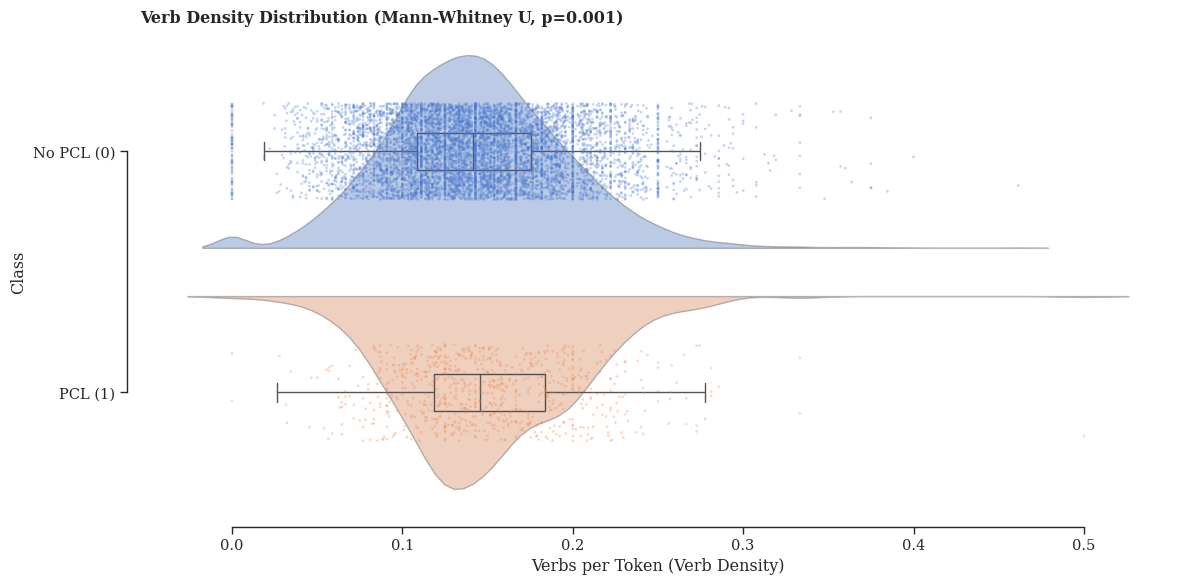

In [21]:
g0 = train_df[train_df["binary_label"] == 0]["verb_density"]
g1 = train_df[train_df["binary_label"] == 1]["verb_density"]
u_stat, p_val = mannwhitneyu(g0, g1)

fig, ax = plt.subplots(figsize=(12, 6))

# density
sns.violinplot(
    data=train_df,
    x="verb_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    inner=None,
    split=True,
    alpha=0.4,
    ax=ax,
    legend=False
)

# individual points
sns.stripplot(
    data=train_df,
    x="verb_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    size=2,
    alpha=0.3,
    jitter=0.2,
    ax=ax,
    legend=False
)

# summary stats
sns.boxplot(
    data=train_df,
    x="verb_density",
    y="binary_label",
    orient='h',
    hue="binary_label",
    width=0.15,
    showfliers=False,
    boxprops={"facecolor": "none", "edgecolor": "0.3"},
    ax=ax,
    legend=False
)

plt.title(
    f"Verb Density Distribution (Mann-Whitney U, p={p_val:.3f})",
    loc="left",
    fontweight="bold"
)
ax.set_yticklabels(["No PCL (0)", "PCL (1)"])
ax.set_ylabel("Class")
ax.set_xlabel("Verbs per Token (Verb Density)")

sns.despine(trim=True, offset=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "verb_density.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * While the Mann-Whitney U test determined a statistical difference in distribution (both for adjective and verb densities).
> * However, for both plots, the visual overlap suggests this difference is marginal and that the feature would not provide a discriminatory signal for classification.

### Named Entity Recognition (NER)

We identify which geopolitical entities (GPE) are most associated with PCL.

In [22]:
# !python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

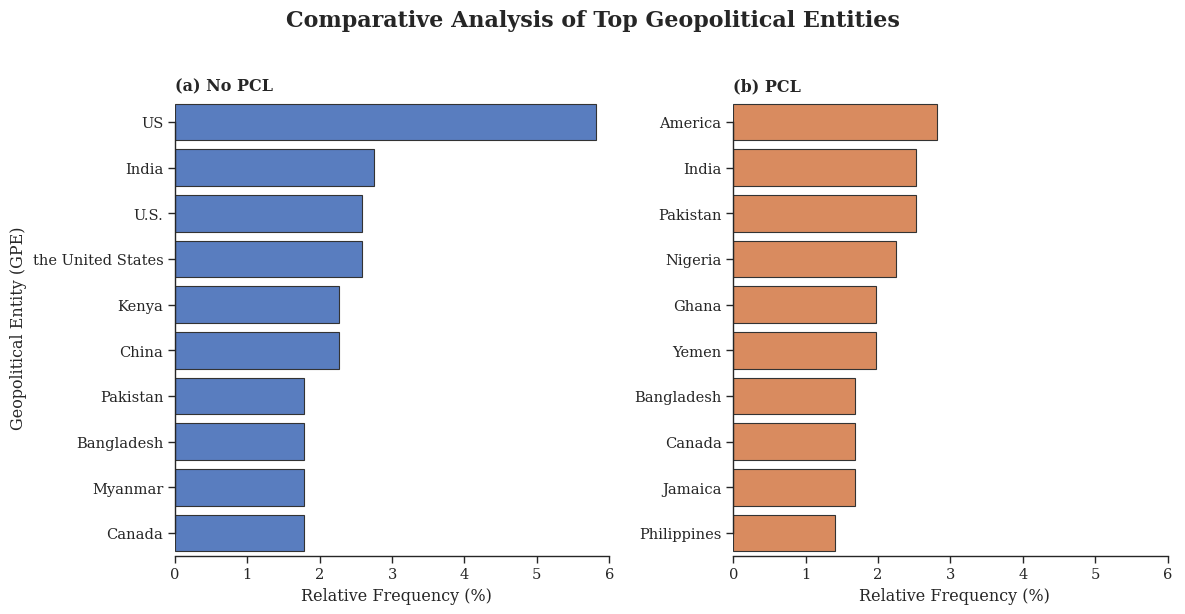

In [23]:
def get_entity_df(text_series, label_name, n=10):
    sample_text = ' '.join(text_series.sample(min(len(text_series), 1000), random_state=42).astype(str))
    doc = nlp(sample_text[:1000000]) # spacy has a character limit for single docs
    gpes = [ent.text.strip() for ent in doc.ents if ent.label_ == "GPE" and len(ent.text) > 1]
    counts = Counter(gpes).most_common(n)
    df = pd.DataFrame(counts, columns=["Location", "Count"])
    df["Class"] = label_name
    df["Percentage"] = (df['Count'] / len(gpes)) * 100
    return df

df_no_pcl_ner = get_entity_df(train_df[train_df["binary_label"]==0]["text"], "No PCL")
df_pcl_ner = get_entity_df(train_df[train_df["binary_label"]==1]["text"], "PCL")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
palette = sns.color_palette("muted", n_colors=2)

sns.barplot(
    data=df_no_pcl_ner,
    x="Percentage",
    y="Location",
    ax=ax1,
    color=palette[0],
    edgecolor=".2"
)
ax1.set_title("(a) No PCL", loc="left", fontweight="bold")
ax1.set_xlabel("Relative Frequency (%)")
ax1.set_ylabel("Geopolitical Entity (GPE)")

sns.barplot(
    data=df_pcl_ner,
    x="Percentage",
    y="Location",
    ax=ax2,
    color=palette[1],
    edgecolor=".2"
)
ax2.set_title("(b) PCL", loc="left", fontweight="bold")
ax2.set_xlabel("Relative Frequency (%)")
ax2.set_ylabel('')

sns.despine(trim=True)
plt.suptitle("Comparative Analysis of Top Geopolitical Entities", fontsize=16, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gpe.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * Both classes share significant commonalities, but the PCL distribution has more Global South nations.
> * Recognizing that geographic bias could act as a latent feature of condescension, conditioning the model on it is sound.

### Embedding Visualization (t-SNE)

We project text embeddings into 2D space to check for cluster separability.

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: models/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Generating RoBERTa embeddings...
Running T-SNE...


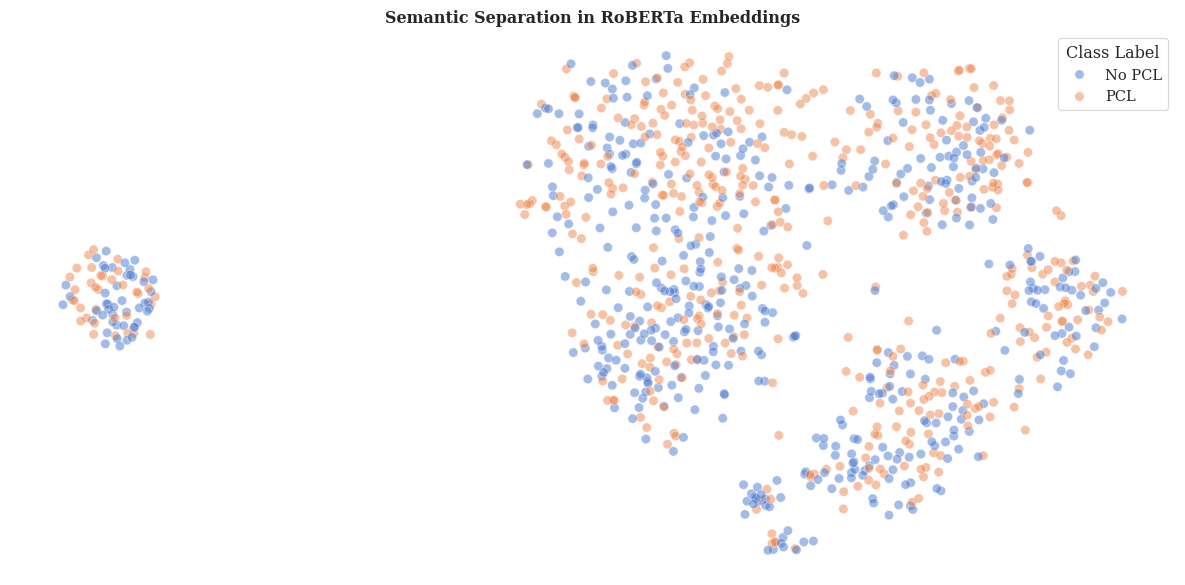

In [24]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("models/roberta-large")
model = AutoModel.from_pretrained("models/roberta-large").to(device)

def get_embeddings(text_list, batch_size=8):
    model.eval()
    embeddings = list()

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Use the [CLS] token (first token) as the sentence embedding
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

    return np.vstack(embeddings)

df_pcl = train_df[train_df["binary_label"] == 1]
df_no_pcl = train_df[train_df["binary_label"] == 0]
n_samples = 500
subset_pcl = df_pcl.sample(n=n_samples, random_state=1)
subset_no_pcl = df_no_pcl.sample(n=n_samples, random_state=1)
subset = pd.concat([subset_pcl, subset_no_pcl]).sample(frac=1, random_state=1)

print("Generating RoBERTa embeddings...")
X_embeddings = get_embeddings(subset['text'].tolist())

print("Running T-SNE...")
tsne = TSNE(n_components=2, random_state=1, perplexity=30, init="pca", learning_rate="auto")
X_embedded = tsne.fit_transform(X_embeddings)

colors = sns.color_palette("muted", n_colors=2)
palette = {"No PCL": colors[0], "PCL": colors[1]}
labels = subset["binary_label"].map({0: "No PCL", 1: "PCL"})
fig, ax = plt.subplots(figsize=(12, 6))

scatter = sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=labels,
    palette=palette,
    alpha=0.5,
    s=45,
    edgecolor='w',
    linewidth=0.5,
    ax=ax
)

ax.set_aspect("auto")
sns.despine(left=True, bottom=True)
ax.set_xticks([])
ax.set_yticks([])

plt.title("Semantic Separation in RoBERTa Embeddings", fontweight="bold")
plt.legend(title="Class Label", loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "tsne_roberta_embeddings.pdf"), bbox_inches="tight", dpi=300)
plt.show()

> **Analysis & Impact:**
> * The t-SNE projection shows no distinct clusters. The PCL samples are scattered diffusely throughout the no-PCL samples.

## Identifying Noise and Artifacts

**Goal:** Ensure data hygiene.

### Duplicate Detection

We check for exact text matches that could cause data leakage.

In [25]:
duplicates_df = train_df[train_df.duplicated(subset=["text"], keep=False)]
num_duplicates = train_df.duplicated(subset=["text"]).sum()

print(f"Total duplicate entries to remove: {num_duplicates}")

# Inspect the labels of duplicates
# If a sentence appears twice with different labels, that is a major conflict we must fix.
if num_duplicates > 0:
    dup_consistency = duplicates_df.groupby("text")["binary_label"].nunique()
    conflicting_dups = dup_consistency[dup_consistency > 1]
    print(f"Duplicates with conflicting labels: {len(conflicting_dups)}")

Total duplicate entries to remove: 0


> **Analysis & Impact:**
> * Zero duplicates were found in the training set.

### HTML & Formatting Artifacts

We scan for leftover HTML tags from web scraping.

In [26]:
html_pattern = r"<[^>]+>"
entity_pattern = r"&[a-z]+;"

def count_artifacts(text):
    tags = re.findall(html_pattern, str(text))
    entities = re.findall(entity_pattern, str(text))
    return len(tags) + len(entities)

train_df["artifact_count"] = train_df["text"].apply(count_artifacts)
noisy_rows = train_df[train_df["artifact_count"] > 0]

print(f"Rows containing HTML artifacts: {len(noisy_rows)}")
if len(noisy_rows) > 0:
    print(f"Max artifacts in a single row: {train_df["artifact_count"].max()}")
    print("Sample noisy text:")
    sample_text = noisy_rows.iloc[0]["text"]
    print(sample_text[:200])

Rows containing HTML artifacts: 374
Max artifacts in a single row: 6
Sample noisy text:
Apart from Pakistan and hosts England , Bangladesh disabled cricket team will also participate in the tournament . <h> Shahid Afridi bags 11 Man of the Match awards in T20Is ( Most by any player ) <h>


> **Analysis & Impact:**
> * Some rows contain HTML artifacts. That can introduce noise and confuse the tokenizer.
> * We need to clean the text before tokenization (e.g., with regular expressions).

### Outlier Inspection

In [27]:
short_outliers = train_df[train_df["seq_len"] < 5]
print(f"Number of short outliers (< 5 words): {len(short_outliers)}")
if len(short_outliers) > 0:
    print("Sample short outliers:")
    display(short_outliers[["par_id", "text", "binary_label"]].head())

Number of short outliers (< 5 words): 11
Sample short outliers:


,par_id,text,binary_label
310,318,The Filipino immigrant,0
1401,1434,Volunteer helps earliest refugees,0
1559,1595,UTI in pregnant women,0
1620,1657,refugees,0
1911,1955,Review refugee law,0


> **Analysis & Impact:**
> * We found a small number of short outliers (< 5 words). These appear to be captions or search keywords rather than full sentences.
> * These lack the context required to determine condescension and are likely labeling noise.
> * We need to filter them during preprocessing.
> * 2 of the short outliers are part of the official development split.